# Deep Learning Model Analysis and Fine-Tuning

This notebook covers the detailed evaluation of the Phase 1 champion model, followed by Phase 2 optimizer fine-tuning. We follow the structure outlined in the paper for reporting results.

## IV. EXPERIMENTS AND RESULTS

### A. Quantitative Performance
We summarize the performance metrics and visualize the training dynamics of our Phase 1 champion: **MobileNetV2 (ImageNet + 0.1 Dropout)**.

--- Champion Quantitative Performance ---


,Experiment,train_acc,train_loss,val_acc,val_f1,val_loss,val_precision,val_recall,test_acc,test_f1,test_loss,test_precision,test_recall
3,mobilenet_v2-l1_imagenet-dr_0.1,NaN,NaN,0.890449,0.895511,0.28958,0.896929,0.89634,0.883333,0.886336,0.324702,0.880701,0.893476


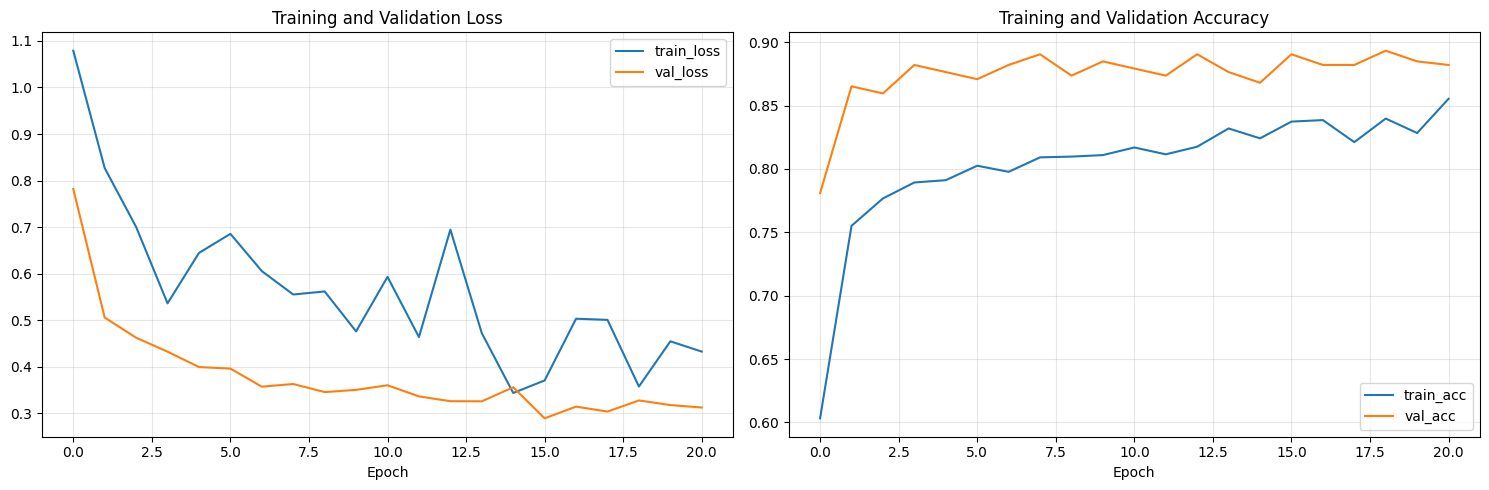

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# 1. Load Consolidated Metrics
metrics_path = Path("../../artifacts/grid_search_mobilenet_v2_phase1_metrics.csv")
if metrics_path.exists():
    df = pd.read_csv(metrics_path)
    champion_name = "mobilenet_v2-l1_imagenet-dr_0.1"
    champion_row = df[df["Experiment"] == champion_name]

    print("--- Champion Quantitative Performance ---")
    display(champion_row)
else:
    print("Metrics summary not found.")

# 2. Load Training History for Curves
history_dir = Path("../../artifacts/logs/mobilenet_v2-l1_imagenet-dr_0.1")
history_files = list(history_dir.glob("version_*/metrics.csv"))
if history_files:
    dfs = [pd.read_csv(f) for f in history_files]
    history = pd.concat(dfs, ignore_index=True)
    # Aggregate by epoch (taking max for accuracies/losses since lightning logs multiple steps)
    agg_dict = {}
    for col in history.columns:
        if "loss" in col:
            agg_dict[col] = "mean"
        elif "acc" in col or "f1" in col:
            agg_dict[col] = "max"

    epoch_data = (
        history.groupby("epoch")
        .agg(agg_dict)
        .dropna(
            subset=[
                "train_loss",
                "val_loss" if "val_loss" in history.columns else "train_loss",
            ]
        )
    )

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Curves
    loss_cols = [c for c in ["train_loss", "val_loss"] if c in epoch_data.columns]
    epoch_data[loss_cols].plot(ax=ax[0])
    ax[0].set_title("Training and Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True, alpha=0.3)

    # Accuracy Curves
    avail_acc = [c for c in ["train_acc", "val_acc"] if c in epoch_data.columns]
    epoch_data[avail_acc].plot(ax=ax[1])
    ax[1].set_title("Training and Validation Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Training history not found.")

### B. Error Analysis
We perform t-SNE embedding analysis to visualize model separability and inspect the top confident errors.

In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from jute_disease.models.dl.classifier import Classifier
from jute_disease.models.dl.backbone import TimmBackbone
from jute_disease.data.datamodule import DataModule
import time

from torch.utils.data import ConcatDataset

dm = DataModule(data_dir="../../data/ml_split", batch_size=32)
dm.setup("test")
dm.setup("fit")
val_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()
pooled_dataset = ConcatDataset([dm.jute_val, dm.jute_test])

champion_dir = Path("../../artifacts/checkpoints/mobilenet_v2-l1_imagenet-dr_0.1")
ckpt_path = list(champion_dir.glob("*.ckpt"))[0]
backbone = TimmBackbone(model_name="mobilenetv2_100")
model = Classifier.load_from_checkpoint(ckpt_path, feature_extractor=backbone)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Inference and Time Tracking
all_features = []
all_preds = []
all_targets = []
all_probs = []
start_time = time.time()

# Pool Val and Test for broader analysis
loaders = [("Val", val_loader), ("Test", test_loader)]

with torch.no_grad():
    for name, loader in loaders:
        for x, y in loader:
            x = x.to(device)
            # Extract features
            feat = model.feature_extractor(x)
            logits = model.classifier(feat)
            probs = F.softmax(logits, dim=1)

            all_features.append(feat.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y)

end_time = time.time()
total_imgs = len(pooled_dataset)
inf_time_per_img = (end_time - start_time) / total_imgs
print(f"Total images processed: {total_imgs}")
print(f"Inference time per image: {inf_time_per_img*1000:.2f} ms")

features = torch.cat(all_features).numpy()
preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()
probs = torch.cat(all_probs).numpy()

/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-05 21:18:36,177 - timm.models._builder - INFO - Loading pretrained weights from Hugging Face hub (timm/mobilenetv2_100.ra_in1k)
2026-03-05 21:18:36,614 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/timm/mobilenetv2_100.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-03-05 21:18:36,624 - timm.models._hub - INFO - [timm/mobilenetv2_100.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Total images processed: 716


#### t-SNE Feature Embeddings
We visualize the high-dimensional feature vectors to see how well the classes are separated in latent space (Val + Test).

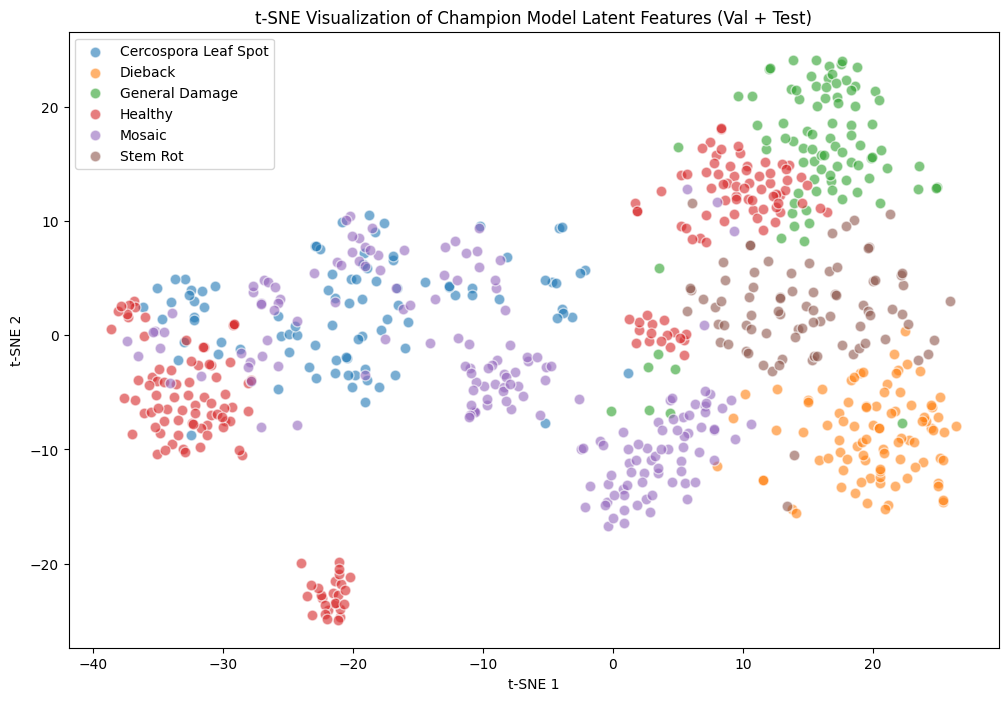

In [3]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feat_2d = tsne.fit_transform(features)

plt.figure(figsize=(12, 8))
for i, cls in enumerate(dm.classes):
    mask = targets == i
    plt.scatter(
        feat_2d[mask, 0], feat_2d[mask, 1], label=cls, alpha=0.6, edgecolors="w", s=60
    )

plt.legend()
plt.title("t-SNE Visualization of Champion Model Latent Features (Val + Test)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

#### UMAP Feature Embeddings
We also compute UMAP embeddings, which often preserve more global structure than t-SNE (Val + Test).

/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


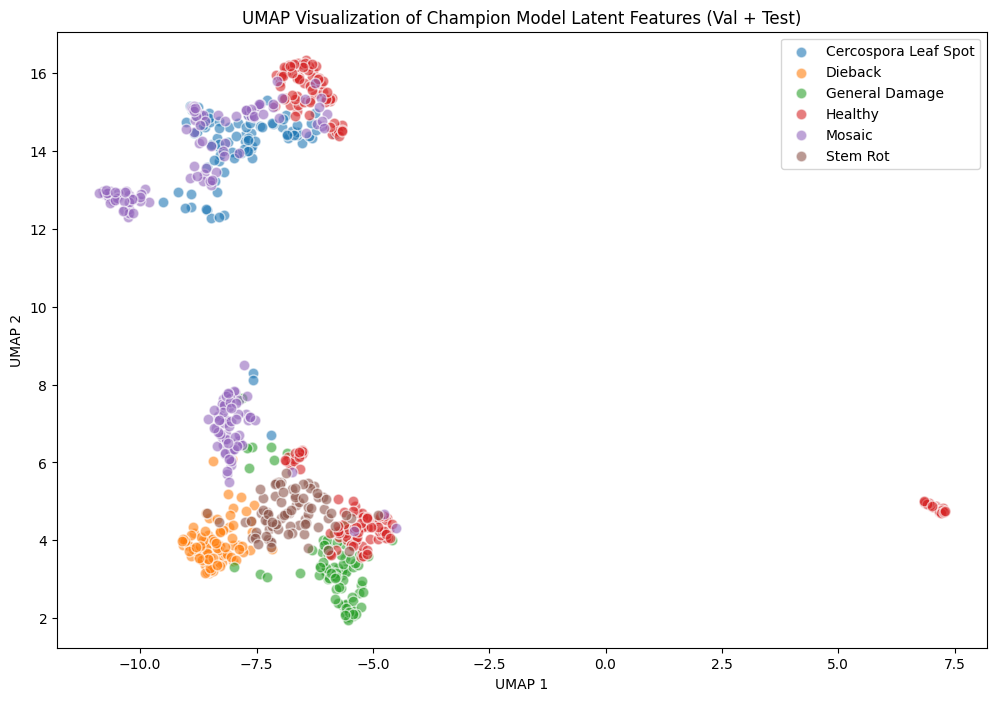

In [4]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
feat_umap = reducer.fit_transform(features)

plt.figure(figsize=(12, 8))
for i, cls in enumerate(dm.classes):
    mask = targets == i
    plt.scatter(
        feat_umap[mask, 0],
        feat_umap[mask, 1],
        label=cls,
        alpha=0.6,
        edgecolors="w",
        s=60,
    )

plt.legend()
plt.title("UMAP Visualization of Champion Model Latent Features (Val + Test)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

#### Top 10 Most Confident Errors
We inspect images where the model was highly confident but incorrect.

IndexError: list index out of range

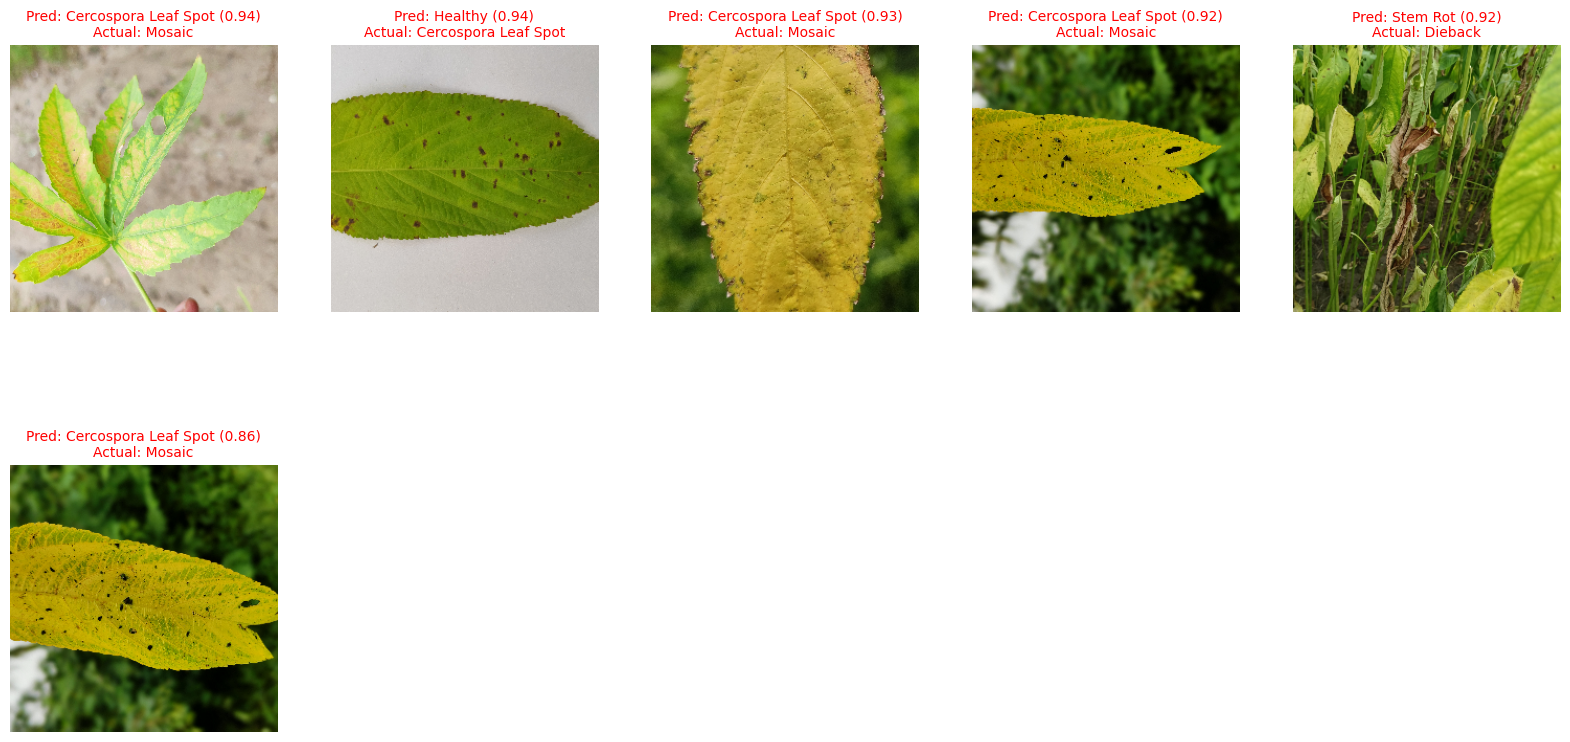

In [5]:
is_wrong = preds != targets
wrong_indices = np.where(is_wrong)[0]

if len(wrong_indices) > 0:
    # Prob of the predicted (wrong) class
    wrong_probs = [probs[i, preds[i]] for i in wrong_indices]
    sorted_wrong = np.argsort(wrong_probs)[::-1][:10]
    top_wrong_idx = wrong_indices[sorted_wrong]

    plt.figure(figsize=(20, 10))
    for i, idx in enumerate(top_wrong_idx):
        img, label = pooled_dataset[idx]
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = (
            img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        ).clip(0, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_disp)
        plt.title(
            f"Pred: {dm.classes[preds[idx]]} ({probs[idx, preds[idx]]:.2f})\nActual: {dm.classes[targets[idx]]}",
            color="red",
            fontsize=10,
        )
        plt.axis("off")
    plt.suptitle("Top 10 Most Confident Incorrect Predictions", fontsize=16)
    plt.show()
else:
    print("No errors found in test set!")

### C. Model Interpretability
We use Grad-CAM to visualize where the model focuses its attention when making predictions.

In [ ]:
from captum.attr import LayerGradCam
import matplotlib.cm as cm
from scipy.ndimage import zoom

# We target the last convolutional block of MobileNetV2
target_layer = model.feature_extractor.backbone.conv_head
lgc = LayerGradCam(model, target_layer)

num_samples = 5
num_classes = len(dm.classes)
plt.figure(figsize=(20, 4 * num_classes))
np.random.seed(42)

plot_idx = 1
for class_idx in range(num_classes):
    class_name = dm.classes[class_idx]
    all_class_indices = np.where(targets == class_idx)[0]

    # Select up to 5 random samples for this class
    n = min(len(all_class_indices), num_samples)
    selected_indices = np.random.choice(all_class_indices, n, replace=False)

    for idx in selected_indices:
        img, label = pooled_dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)

        attribution = lgc.attribute(input_tensor, target=label)
        # Standardize normalization for visualization
        heatmap = attribution.squeeze().cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)
        if heatmap.max() > 0:
            heatmap /= heatmap.max()

        # Rescale image for display
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = (
            img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        ).clip(0, 1)

        h, w = img_disp.shape[:2]
        heatmap_upsampled = zoom(heatmap, (h / heatmap.shape[0], w / heatmap.shape[1]))

        plt.subplot(num_classes, num_samples, plot_idx)
        plt.imshow(img_disp)
        plt.imshow(heatmap_upsampled, cmap="jet", alpha=0.4)
        if (plot_idx - 1) % num_samples == 0:
            plt.ylabel(class_name, fontsize=14, fontweight="bold")

        plt.title(f"Conf: {probs[idx, label]:.2f}")
        plt.xticks([])
        plt.yticks([])
        plot_idx += 1

    # Fill empty slots in the grid if samples < num_samples
    plot_idx += num_samples - n

plt.suptitle(
    "Model Interpretability: Grad-CAM Heatmaps (5 Samples per Class)",
    fontsize=20,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Phase 2: Optimizer Grid Search
Now that we have successfully evaluated our Phase 1 champion, we proceed to Phase 2b to find the optimal Learning Rate and Weight Decay parameters.

In [ ]:
# !make grid-search-finetune